# Kendalls Tau – einfach erklärt

> Quelle: [numiqo.de](https://numiqo.de/tutorial/kendalls-tau)
> Autor: Dr. Mathias Jesussek | Aktualisiert: 19.01.2026

**Kendalls Tau** (τ) ist ein nichtparametrischer Korrelationskoeffizient
basierend auf **konkordanten** und **diskordanten Paaren**.

**Formel:**
$$\tau = \frac{K - D}{K + D} = \frac{S}{\binom{n}{2}}, \quad S = K - D, \quad \binom{n}{2} = \frac{n(n-1)}{2}$$

| Begriff | Bedeutung |
|---|---|
| **Konkordantes Paar** (K) | Beide Variablen ändern sich in gleicher Richtung |
| **Diskordantes Paar** (D) | Beide Variablen ändern sich in entgegengesetzter Richtung |

**z-Approximation (n > 40):**
$$z = \frac{3\tau\sqrt{n(n-1)}}{\sqrt{2(2n+5)}}$$

**Wann Kendalls Tau statt Spearman?**
- Sehr wenige Daten mit vielen Rangbindungen
- Tau ist robuster bei kleinen n mit Bindungen
- Tau hat eine direktere Wahrscheinlichkeitsinterpretation

**Stärke (gleiche Tabelle wie Pearson/Spearman):**

| |τ| | Stärke |
|---|---|
| 0,0 – 0,1 | Keine |
| 0,1 – 0,3 | Gering |
| 0,3 – 0,5 | Mittel |
| 0,5 – 0,7 | Hoch |
| 0,7 – 1,0 | Sehr hoch |

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import kendalltau, spearmanr
from itertools import combinations

np.random.seed(42)
print("Bibliotheken erfolgreich geladen.")

Bibliotheken erfolgreich geladen.


## 1. Kernidee: Konkordante und diskordante Paare

**Konkordantes Paar:** Person i und j – wenn Person i bei beiden Variablen
höher rankt als Person j (oder beide niedriger), stimmen die Richtungen überein.

**Diskordantes Paar:** Die Richtungen widersprechen sich.

**Beispiel:** Ärztin und Arzt sortieren 6 Patienten nach Gesundheitszustand.
- Ärztin-Rangfolge (Referenz): 1, 2, 3, 4, 5, 6
- Arzt-Ränge: 3, 1, 4, 2, 6, 5

**Erwartetes numiqo-Ergebnis:** τ = 0,47, p = 0,188

In [2]:
# numiqo-Datensatz: Ärztliche Einschätzung
aerztin = np.array([1, 2, 3, 4, 5, 6])  # Referenz
arzt    = np.array([3, 1, 4, 2, 6, 5])  # Zweite Einschätzung
n = len(aerztin)

# Konkordante und diskordante Paare manuell zählen
K, D = 0, 0
paare_liste = []
for i, j in combinations(range(n), 2):
    sign_x = np.sign(aerztin[j] - aerztin[i])
    sign_y = np.sign(arzt[j]    - arzt[i])
    produkt = sign_x * sign_y
    if produkt > 0:
        K += 1
        typ = "+"
    elif produkt < 0:
        D += 1
        typ = "-"
    else:
        typ = "0"
    paare_liste.append((i+1, j+1, aerztin[i], aerztin[j],
                        arzt[i], arzt[j], typ))

print("Alle Paare")
print("(i,j)  Ärzt.i  Aerzt.j  Arzt.i  Arzt.j  Konkord.")
for p in paare_liste:
    print("(" + str(p[0]) + "," + str(p[1]) + ")   " +
          str(p[2]) + "        " + str(p[3]) + "        " +
          str(p[4]) + "       " + str(p[5]) + "       " + p[6])
print()
print("K (konkordant) = " + str(K) + "  (numiqo: 11)")
print("D (diskordant) = " + str(D) + "  (numiqo: 4)")
print()

tau_man = (K - D) / (K + D)
n_pairs = n * (n-1) // 2
S       = K - D
tau_alt = S / n_pairs  # alternative Formel

print("tau = (K-D)/(K+D) = (" + str(K) + "-" + str(D) + ")/(" +
      str(K) + "+" + str(D) + ") = " + str(round(tau_man, 4)) +
      "  (numiqo: 0.47)")
print("tau = S/C(n,2) = " + str(S) + "/" + str(n_pairs) + " = " +
      str(round(tau_alt, 4)))
print()

# scipy Kontrolle
tau_sci, p_sci = kendalltau(aerztin, arzt)
print("scipy: tau=" + str(round(tau_sci, 4)) + "  p=" + str(round(p_sci, 4)))
print()
print("APA: tau(4) = .47, p = .188 -> nicht signifikant (n zu klein)")

Alle Paare
(i,j)  Ärzt.i  Aerzt.j  Arzt.i  Arzt.j  Konkord.
(1,2)   1        2        3       1       -
(1,3)   1        3        3       4       +
(1,4)   1        4        3       2       -
(1,5)   1        5        3       6       +
(1,6)   1        6        3       5       +
(2,3)   2        3        1       4       +
(2,4)   2        4        1       2       +
(2,5)   2        5        1       6       +
(2,6)   2        6        1       5       +
(3,4)   3        4        4       2       -
(3,5)   3        5        4       6       +
(3,6)   3        6        4       5       +
(4,5)   4        5        2       6       +
(4,6)   4        6        2       5       +
(5,6)   5        6        6       5       -

K (konkordant) = 11  (numiqo: 11)
D (diskordant) = 4  (numiqo: 4)

tau = (K-D)/(K+D) = (11-4)/(11+4) = 0.4667  (numiqo: 0.47)
tau = S/C(n,2) = 7/15 = 0.4667

scipy: tau=0.4667  p=0.2722

APA: tau(4) = .47, p = .188 -> nicht signifikant (n zu klein)


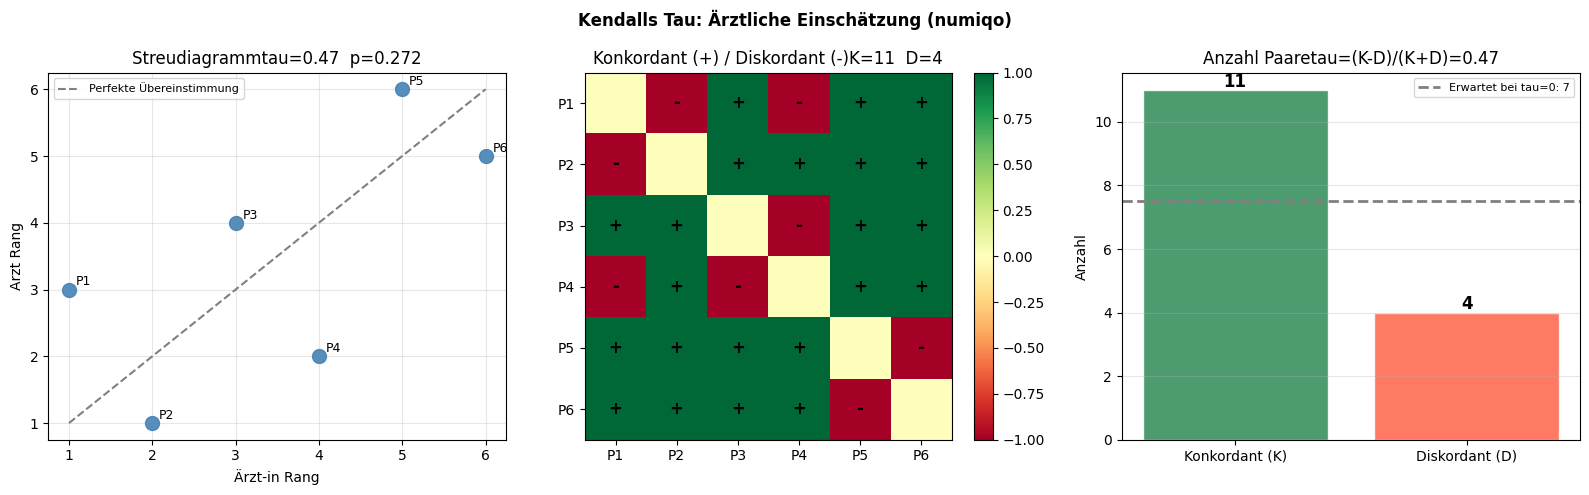

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("Kendalls Tau: Ärztliche Einschätzung (numiqo)",
             fontsize=12, fontweight="bold")

# 1. Streudiagramm
axes[0].scatter(aerztin, arzt, color="steelblue", s=100, alpha=0.9, zorder=3)
for i in range(n):
    axes[0].annotate("P" + str(i+1), (aerztin[i], arzt[i]),
                     textcoords="offset points", xytext=(5, 3), fontsize=9)
# Diagonale (perfekte Übereinstimmung)
axes[0].plot([1, 6], [1, 6], color="gray", linestyle="--", linewidth=1.5,
             label="Perfekte Übereinstimmung")
axes[0].set_title("Streudiagrammtau=" + str(round(tau_sci, 2)) +
                  "  p=" + str(round(p_sci, 3)))
axes[0].set_xlabel("Ärzt-in Rang")
axes[0].set_ylabel("Arzt Rang")
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

# 2. Paare-Matrix als Heatmap
n_p = len(paare_liste)
matrix = np.zeros((n, n))
for p in paare_liste:
    i, j = p[0]-1, p[1]-1
    val = 1 if p[6] == "+" else (-1 if p[6] == "-" else 0)
    matrix[i, j] = val
    matrix[j, i] = val

im = axes[1].imshow(matrix, cmap="RdYlGn", vmin=-1, vmax=1, aspect="auto")
axes[1].set_xticks(range(n))
axes[1].set_yticks(range(n))
axes[1].set_xticklabels(["P"+str(i+1) for i in range(n)])
axes[1].set_yticklabels(["P"+str(i+1) for i in range(n)])
for p in paare_liste:
    i, j = p[0]-1, p[1]-1
    axes[1].text(j, i, p[6], ha="center", va="center",
                 fontsize=12, fontweight="bold")
    axes[1].text(i, j, p[6], ha="center", va="center",
                 fontsize=12, fontweight="bold")
plt.colorbar(im, ax=axes[1])
axes[1].set_title("Konkordant (+) / Diskordant (-)K=" + str(K) + "  D=" + str(D))

# 3. K und D als Balken
axes[2].bar(["Konkordant (K)", "Diskordant (D)"], [K, D],
            color=["seagreen", "tomato"], edgecolor="white", alpha=0.85)
axes[2].axhline(n_pairs/2, color="gray", linestyle="--", linewidth=2,
                label="Erwartet bei tau=0: " + str(n_pairs//2))
axes[2].set_title("Anzahl Paaretau=(K-D)/(K+D)=" + str(round(tau_man, 2)))
axes[2].set_ylabel("Anzahl")
axes[2].legend(fontsize=8)
axes[2].grid(axis="y", alpha=0.3)
for i, (lbl, val) in enumerate([("K", K), ("D", D)]):
    axes[2].text(i, val + 0.1, str(val), ha="center", fontsize=12,
                 fontweight="bold")

plt.tight_layout()
plt.show()

## 2. Schritt-für-Schritt-Berechnung

**Methode (numiqo-Tutorial):**
1. Arzt-Ränge als Sequenz aufschreiben: [3, 1, 4, 2, 6, 5]
2. Für jeden Wert: alle nachfolgenden Werte vergleichen
3. Nachfolgender größer → „+" (konkordant); kleiner → „−" (diskordant)
4. K = Anzahl „+", D = Anzahl „−"
5. τ = (K − D) / (K + D)

In [4]:
print("Schritt-für-Schritt: Kendalls Tau (numiqo-Methode)")
print()
print("Arzt-Ränge: " + str(arzt.tolist()))
print()
print("Für jeden Rang: Vergleich mit allen nachfolgenden")
print()
K_m, D_m = 0, 0
for i in range(n):
    vergleiche = []
    for j in range(i+1, n):
        if arzt[j] > arzt[i]:
            vergleiche.append("+")
            K_m += 1
        elif arzt[j] < arzt[i]:
            vergleiche.append("-")
            D_m += 1
        else:
            vergleiche.append("0")
    print("Rang " + str(int(arzt[i])) + ": " + str(vergleiche))
print()
print("K = " + str(K_m) + "  D = " + str(D_m))
print("tau = (" + str(K_m) + " - " + str(D_m) + ") / (" +
      str(K_m) + " + " + str(D_m) + ") = " + str(round((K_m-D_m)/(K_m+D_m), 4)))
print()
print("Alternative Formel:")
print("S = K - D = " + str(K_m - D_m))
print("C(6,2) = " + str(n_pairs))
print("tau = " + str(K_m-D_m) + " / " + str(n_pairs) +
      " = " + str(round((K_m-D_m)/n_pairs, 4)))

Schritt-für-Schritt: Kendalls Tau (numiqo-Methode)

Arzt-Ränge: [3, 1, 4, 2, 6, 5]

Für jeden Rang: Vergleich mit allen nachfolgenden

Rang 3: ['-', '+', '-', '+', '+']
Rang 1: ['+', '+', '+', '+']
Rang 4: ['-', '+', '+']
Rang 2: ['+', '+']
Rang 6: ['-']
Rang 5: []

K = 11  D = 4
tau = (11 - 4) / (11 + 4) = 0.4667

Alternative Formel:
S = K - D = 7
C(6,2) = 15
tau = 7 / 15 = 0.4667


## 3. Kendalls Tau vs. Spearman: Wann welcher?

**Tau ist oft kleiner als ρ** für denselben Datensatz – das ist normal,
sie messen auf unterschiedlichen Skalen.

**Faustregel:**
- Viele Bindungen + kleines n → **Kendalls Tau**
- Sonst → **Spearman** (häufiger in der Praxis)

> Tau hat eine direkte Wahrscheinlichkeitsinterpretation:
> τ = P(konkordant) − P(diskordant)

Kendalls Tau vs. Spearman (gleiche Daten)

Normal, kein Ausreisser:
  Kendalls Tau: tau=1.0  p=0.0
  Spearman rho: rho=1.0  p=0.0

Mit Ausreisser:
  Kendalls Tau: tau=0.582  p=0.0
  Spearman rho: rho=0.735  p=0.0

Viele Bindungen (ordinal):
  Kendalls Tau: tau=0.673  p=0.0
  Spearman rho: rho=0.748  p=0.0



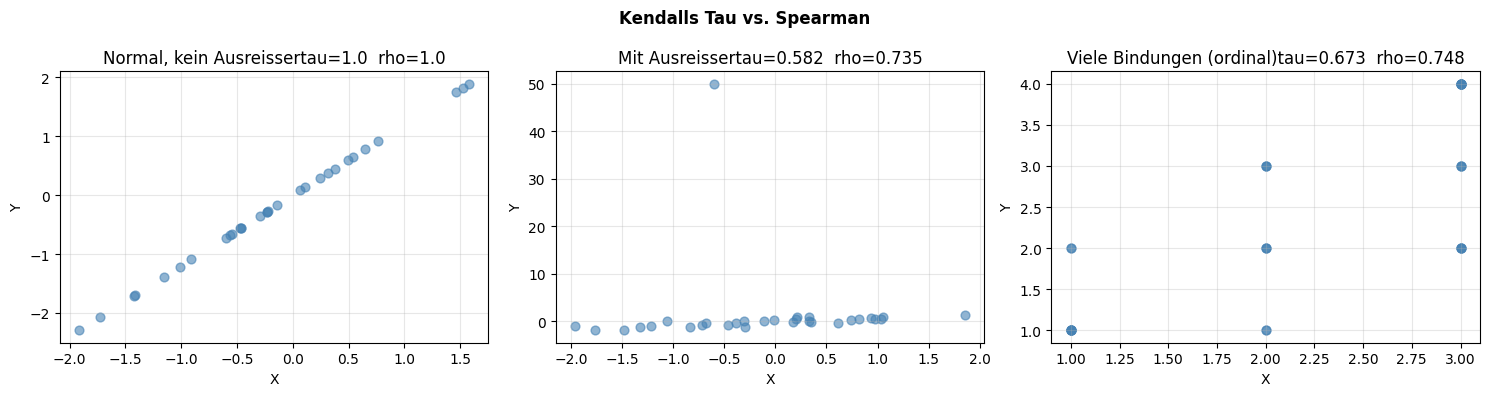

In [5]:
# Kendalls Tau vs. Spearman auf verschiedenen Datensätzen
np.random.seed(42)
n_vgl = 30

print("Kendalls Tau vs. Spearman (gleiche Daten)")
print()

szenarien_k = [
    ("Normal, kein Ausreisser", np.random.normal(0,1,n_vgl), None),
    ("Mit Ausreisser",          np.random.normal(0,1,n_vgl), "ausreisser"),
    ("Viele Bindungen (ordinal)", np.random.choice(range(1,4),n_vgl), "ordinal"),
]

for name, x_k, typ in szenarien_k:
    np.random.seed(42)
    x_k2 = x_k.copy()
    if typ == "ausreisser":
        y_k = 0.7*x_k2 + np.random.normal(0, 0.5, n_vgl)
        y_k[0] = 50
    elif typ == "ordinal":
        y_k = x_k2 + np.random.choice(range(-1, 2), n_vgl)
        y_k = np.clip(y_k, 1, 5)
    else:
        y_k = 0.7*x_k2 + np.random.normal(0, 0.5, n_vgl)

    tau_k, p_tau = kendalltau(x_k2, y_k)
    rho_k, p_rho = spearmanr(x_k2, y_k)
    print(name + ":")
    print("  Kendalls Tau: tau=" + str(round(tau_k, 3)) +
          "  p=" + str(round(p_tau, 4)))
    print("  Spearman rho: rho=" + str(round(rho_k, 3)) +
          "  p=" + str(round(p_rho, 4)))
    print()

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Kendalls Tau vs. Spearman", fontsize=12, fontweight="bold")

for ax, (name, x_k, typ) in zip(axes, szenarien_k):
    np.random.seed(42)
    x_k2 = x_k.copy()
    if typ == "ausreisser":
        y_k = 0.7*x_k2 + np.random.normal(0, 0.5, n_vgl)
        y_k[0] = 50
    elif typ == "ordinal":
        y_k = x_k2 + np.random.choice(range(-1, 2), n_vgl)
        y_k = np.clip(y_k, 1, 5)
    else:
        y_k = 0.7*x_k2 + np.random.normal(0, 0.5, n_vgl)

    tau_k, _ = kendalltau(x_k2, y_k)
    rho_k, _ = spearmanr(x_k2, y_k)

    ax.scatter(x_k2, y_k, color="steelblue", alpha=0.6, s=40)
    ax.set_title(name + "tau=" + str(round(tau_k, 3)) +
                 "  rho=" + str(round(rho_k, 3)))
    ax.set_xlabel("X")
    ax.set_ylabel("Y")
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [7]:
# APA-Ausgabe-Funktion
def kendalls_tau_apa(x, y, var_x="Variable A", var_y="Variable B", alpha=0.05):
    x, y = np.asarray(x, dtype=float), np.asarray(y, dtype=float)
    n_f  = len(x)
    tau_f, p_f = kendalltau(x, y)

    def interpret_tau(t):
        at = abs(t)
        if at < 0.1: return "keine Korrelation"
        elif at < 0.3: return "geringe Korrelation"
        elif at < 0.5: return "mittlere Korrelation"
        elif at < 0.7: return "hohe Korrelation"
        return "sehr hohe Korrelation"

    richtg = "positiv" if tau_f > 0 else "negativ"
    sig    = "signifikant" if p_f < alpha else "NICHT signifikant"
    p_str  = "p < .001" if p_f < 0.001 else "p = " + str(round(p_f, 3)).replace("0.", ".")

    print("Kendalls Tau: " + var_x + " x " + var_y)
    print("n=" + str(n_f) + "  tau=" + str(round(tau_f, 4)) + "  " + p_str)
    print("Zusammenhang: " + interpret_tau(tau_f) + " (" + richtg + ")")
    print("Ergebnis: " + sig)
    print()
    if p_f < alpha:
        print("APA: tau(" + str(n_f-2) + ") = " +
              str(round(tau_f, 2)) + ", " + p_str)
    print()

# numiqo-Hauptbeispiel
kendalls_tau_apa(aerztin, arzt, "rzt-in", "Arzt")
print()

# Größeres signifikantes Beispiel
np.random.seed(5)
x_sig = np.random.choice(range(1, 6), 50)
y_sig = x_sig + np.random.choice(range(-1, 2), 50)
y_sig = np.clip(y_sig, 1, 5)
kendalls_tau_apa(x_sig, y_sig, "Kundenzufriedenheit", "Weiterempfehlung")

Kendalls Tau: rzt-in x Arzt
n=6  tau=0.4667  p = .272
Zusammenhang: mittlere Korrelation (positiv)
Ergebnis: NICHT signifikant



Kendalls Tau: Kundenzufriedenheit x Weiterempfehlung
n=50  tau=0.7362  p < .001
Zusammenhang: sehr hohe Korrelation (positiv)
Ergebnis: signifikant

APA: tau(48) = 0.74, p < .001



## 4. Zusammenfassung

```
Kendalls Tau – Übersicht
│
├── WAS?
│   Nichtparametrischer Korrelationskoeffizient
│   Basiert auf KONKORDANTEN (K) und DISKORDANTEN (D) Paaren
│   Direkte Wahrscheinlichkeitsinterpretation:
│   tau = P(konkordant) - P(diskordant)
│
├── FORMEL
│   tau = (K - D) / (K + D) = S / C(n,2)
│   S = K - D,  C(n,2) = n*(n-1)/2
│
├── BERECHNUNG
│   1. Paare bilden (alle C(n,2) Kombinationen)
│   2. Für jedes Paar: gleiche Richtung? -> K | Gegenteil? -> D
│   3. tau = (K-D)/(K+D)
│
├── WANN KENDALLS TAU?
│   Viele Bindungen + kleines n -> Kendalls Tau
│   Sonst: Spearman gleichwertig oder bevorzugt
│
├── VERGLEICH MIT SPEARMAN
│   Tau ist i.d.R. kleiner als rho (andere Skala)
│   Beide robust, beide nichtparametrisch
│   Tau robuster bei kleinen n mit Bindungen
│
├── numiqo-BEISPIEL: rztliche Einschätzung (n=6)
│   K=11, D=4, tau=0.47, p=0.188 -> n.s. (n zu klein)
│
└── PYTHON
    from scipy.stats import kendalltau
    tau, p = kendalltau(x, y)
```

---
Quelle: [numiqo.de/tutorial/kendalls-tau](https://numiqo.de/tutorial/kendalls-tau)